# Greeks estimators and discrete delta hedging

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mcengine.reporting.style import apply_style, PALETTE

apply_style()
%matplotlib inline

In [2]:
from mcengine import GBM
from mcengine.products.european import EuropeanOption, DigitalOption
from mcengine.greeks.analytic import bs_greeks, digital_greeks
from mcengine.greeks.monte_carlo import mc_greeks

model = GBM(100.0, 0.05, 0.2)
cases = [
    (EuropeanOption(100.0, 1.0), bs_greeks(100, 100, 1, 0.05, 0.2)),
    (DigitalOption(100.0, 1.0), digital_greeks(100, 100, 1, 0.05, 0.2)),
]
for product, ref in cases:
    print(product.label)
    for method in ("bump", "pathwise", "lr"):
        g = mc_greeks(model, product, method=method, n_paths=200_000, seed=2)
        print(
            f"  {method:9s}"
            + "".join(
                f"  {k} {getattr(g, k):+.5f} (SE {g.std_errors[k]:.1e}, exact {getattr(ref, k):+.5f})"
                for k in ("delta", "gamma")
            )
        )

European call K=100 T=1
  bump       delta +0.63683 (SE 1.3e-03, exact +0.63683)  gamma +0.01868 (SE 2.4e-04, exact +0.01876)
  pathwise   delta +0.63692 (SE 1.3e-03, exact +0.63683)  gamma +0.01872 (SE 6.2e-05, exact +0.01876)
  lr         delta +0.63391 (SE 3.3e-03, exact +0.63683)  gamma +0.01850 (SE 3.1e-04, exact +0.01876)
Digital call K=100 T=1


  bump       delta +0.01859 (SE 2.1e-04, exact +0.01876)  gamma -0.00059 (SE 4.2e-04, exact -0.00033)
  pathwise   delta +0.00000 (SE 0.0e+00, exact +0.01876)  gamma +0.00000 (SE 0.0e+00, exact -0.00033)
  lr         delta +0.01872 (SE 6.2e-05, exact +0.01876)  gamma -0.00033 (SE 5.0e-06, exact -0.00033)


The pathwise estimator returns exactly zero for the digital option: the payoff is flat almost everywhere, so differentiating inside the expectation misses the discontinuity. The likelihood-ratio estimator does not need a differentiable payoff.

## Hedging error vs rebalancing frequency

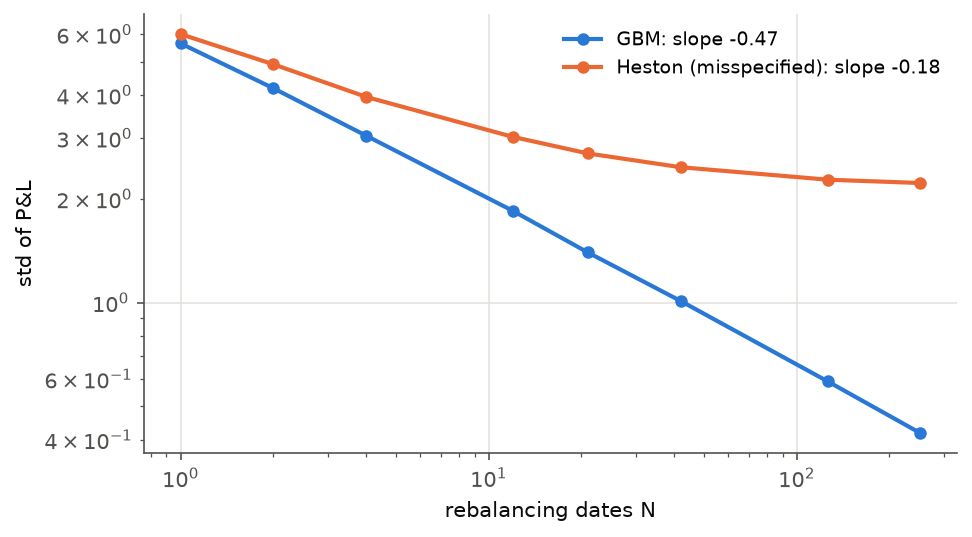

In [3]:
from mcengine.hedging import hedging_experiment, fit_std_slope
from mcengine.models import Heston

freqs = [1, 2, 4, 12, 21, 42, 126, 252]
gbm = hedging_experiment(model, 100.0, 1.0, freqs, hedge_sigma=0.2, n_paths=20_000, seed=3)
heston = hedging_experiment(
    Heston(100.0, 0.05, 0.04, 2.0, 0.04, 0.5, -0.7),
    100.0,
    1.0,
    freqs,
    hedge_sigma=0.2,
    n_paths=20_000,
    seed=3,
)
fig, ax = plt.subplots(figsize=(7, 3.8))
for i, (name, res) in enumerate((("GBM", gbm), ("Heston (misspecified)", heston))):
    ax.loglog(
        freqs,
        [r.std for r in res],
        "o-",
        color=PALETTE[i],
        label=f"{name}: slope {fit_std_slope(res):.2f}",
    )
ax.set_xlabel("rebalancing dates N")
ax.set_ylabel("std of P&L")
ax.legend();